# MITGCM Regional Heat Flux Analysis

**Purpose**: Code for computing the mean fields and spatial gradients across the study region for Forcing.  

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import gsw
from geopy.distance import geodesic
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from lsf import unweighted_lsf, detrend, compute_amp_phase

Set data analysis parameters

In [3]:
# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/regional/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_CCE = ROOT + "AirSeaCoupling"
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'

# Set plotting parameters 
fontsize = 25

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
filename_tflux = PATH + "TFLUX_CCS4_DLY_map_2D.nc"
filename_sflux = PATH + "SFLUX_CCS4_DLY_map_2D.nc"
filename_Qsw = PATH + "oceQsw_CCS4_daily_map_surface.nc"
nc_tflux = Dataset(filename_tflux, 'r')
nc_sflux = Dataset(filename_sflux, 'r')
nc_Qsw = Dataset(filename_Qsw, 'r')

# Extract data variables
lon = nc_tflux.variables['XC'][:]
lat = nc_tflux.variables['YC'][:]
time =  num2date(nc_tflux.variables['time'][:], nc_tflux.variables['time'].units)

Q_net = nc_tflux.variables['TFLUX'][:]
Q_sw = nc_Qsw.variables['oceQsw'][:]
S_flux = nc_sflux.variables['SFLUX'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Grab data from Jan 1, 2016 to Dec 31, 2017 to be consistent with time scale analysis

In [5]:
# Set time index for 2016 through 2017
idx_time = (time_dt >= datetime(2016, 1, 1)) & (time_dt < datetime(2018, 1, 1))

# Subset data to time index
Q_net = Q_net[idx_time, :, :]
Q_sw = Q_sw[idx_time, :, :]
S_flux = S_flux[idx_time, :, :]
time_dt = time_dt[idx_time]

In [31]:
np.shape(lon)

(144,)

Read in bathymetry data

In [6]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Load CCE processed data

In [7]:
# Set start and end times for CCE1 and 2
st_cce1_ctd      = datetime(2016, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
ed_cce1_ctd      = datetime(2017, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       

st_cce2_ctd      = datetime(2020, 1, 1, 0, 0, 0)       
ed_cce2_ctd      = datetime(2021, 12, 31, 23, 59, 59)        

# Set the file name and read in the data file
filename_CCE1_ctd  = PATH_CCE + "/data/CCE/CCE1/CTD/CCE1_CTD_" + str(st_cce1_ctd.year) + str(st_cce1_ctd.month) + str(st_cce1_ctd.day) +  "-" + str(ed_cce1_ctd.year) + str(ed_cce1_ctd.month) + str(ed_cce1_ctd.day) + "_intermediate_gridded_data.nc"
filename_CCE2_ctd  = PATH_CCE + "/data/CCE/CCE2/CTD/CCE2_CTD_" + str(st_cce2_ctd.year) + str(st_cce2_ctd.month) + str(st_cce2_ctd.day) +  "-" + str(ed_cce2_ctd.year) + str(ed_cce2_ctd.month) + str(ed_cce2_ctd.day) + "_intermediate_gridded_data.nc"

#--- CCE 1 ---# 
nc_CCE1_ctd  = Dataset(filename_CCE1_ctd, 'r')

# Extract data variables
lon1             = nc_CCE1_ctd.variables['LON'][:]
lat1             = nc_CCE1_ctd.variables['LAT'][:]

#--- CCE 2 ---# 
nc_CCE2_ctd  = Dataset(filename_CCE2_ctd, 'r')

# Extract data variables
lon2             = nc_CCE2_ctd.variables['LON'][:]
lat2             = nc_CCE2_ctd.variables['LAT'][:]

#--- CCE 3 ---# 
lon3 = -120.53825701527784 % 360
lat3 = 34.44825228022894

Read in CalCOFI stations

In [8]:
# Load CalCOFI csv file 
filename = PATH_calCOFI + "CalCOFIStationOrder.csv"
calCOFI_data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 3, 7, 11),
    invalid_raise=False
)

# Grab stations on line 80.0
calCOFI_line80 = calCOFI_data[calCOFI_data[:, 0] == 80.0] 

# Parse data into separate arrays
calCOFI_stn   = calCOFI_line80[:, 0]
calCOFI_lat   = calCOFI_line80[:, 1]
calCOFI_lon   = calCOFI_line80[:, 2]
calCOFI_depth = calCOFI_line80[:, 3]

Compute the time and mean variance for each forcing term

In [25]:
Q_net_mean = np.mean(Q_net, axis=0)
Q_net_var = np.var(Q_net, ddof=1, axis=0)
Q_net_ratio = np.sqrt(Q_net_var) / Q_net_mean

Q_sw_mean = np.mean(Q_sw, axis=0)
Q_sw_var = np.var(Q_sw, ddof=1, axis=0)
Q_sw_ratio = np.sqrt(Q_sw_var) / Q_sw_mean

Q_nonSW = Q_net - Q_sw
Q_nonsw_mean = np.mean(Q_nonSW, axis=0)
Q_nonsw_var = np.var(Q_nonSW, ddof=1, axis=0)
Q_nonsw_ratio = np.sqrt(Q_nonsw_var) / Q_nonsw_mean

S_flux_mean = np.mean(S_flux, axis=0)
S_flux_var = np.var(S_flux, ddof=1, axis=0)
S_flux_ratio = np.sqrt(S_flux_var) / S_flux_mean

Set plotting parameters

In [10]:
# Set plotting parameters 
fontsize = 25

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# Set plotting parameters for cartopy functions
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35

Plot time mean and variance

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_28788/1905883555.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


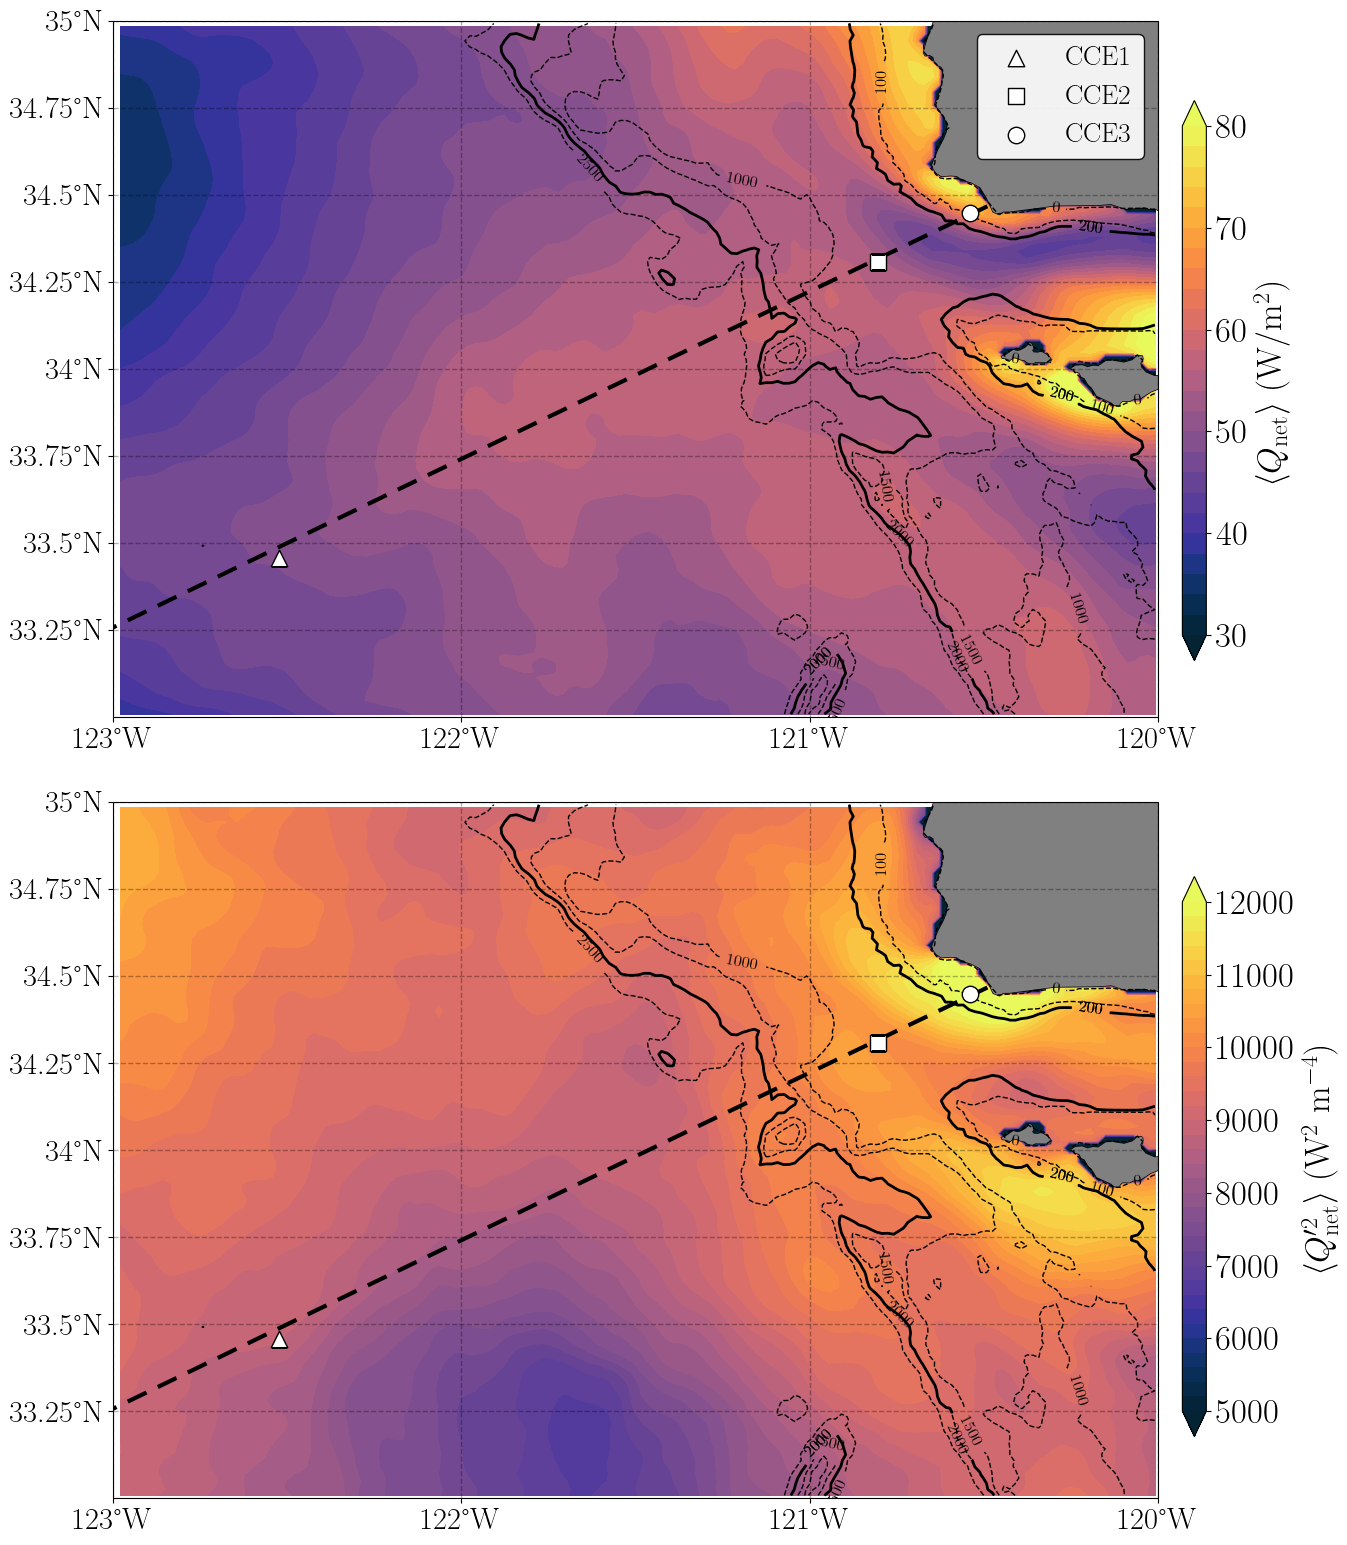

In [11]:
# Set plotting parameters
levels_mean = np.arange(30, 80+2, 2)
levels_var = np.arange(5000, 12000+200, 200)
cmap = cmo.thermal
label_mean = r'$\langle Q_{\mathrm{net}} \rangle$ (W/m$^2$)'
label_var = r"$\langle Q_{\mathrm{net}}'^2 \rangle$ (W$^2$ m$^{-4}$)"

# Create figure
fig, axes = plt.subplots(2,1, figsize=(12, 16), subplot_kw={"projection": projection})

#--- Subplot 1: Time Mean of Potential Density ---#
ax = axes[0]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_net_mean, levels=levels_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree()
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colorbar
cax = plt.axes([0.98, 0.57, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_mean)
cbar.set_ticks(np.arange(30, 80+10, 10))   

# Set legend
ax.legend(
    loc='upper right',
    fontsize=fontsize-5,
    framealpha=0.9,
    edgecolor='black'
)

#--- Subplot 2: Time Variance of Potential Density ---#
ax = axes[1]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_net_var, levels=levels_var,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.98, 0.085, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_var)
cbar.set_ticks(np.arange(5000, 12000+1000, 1000)) 

# Show the plot
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'figS20.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


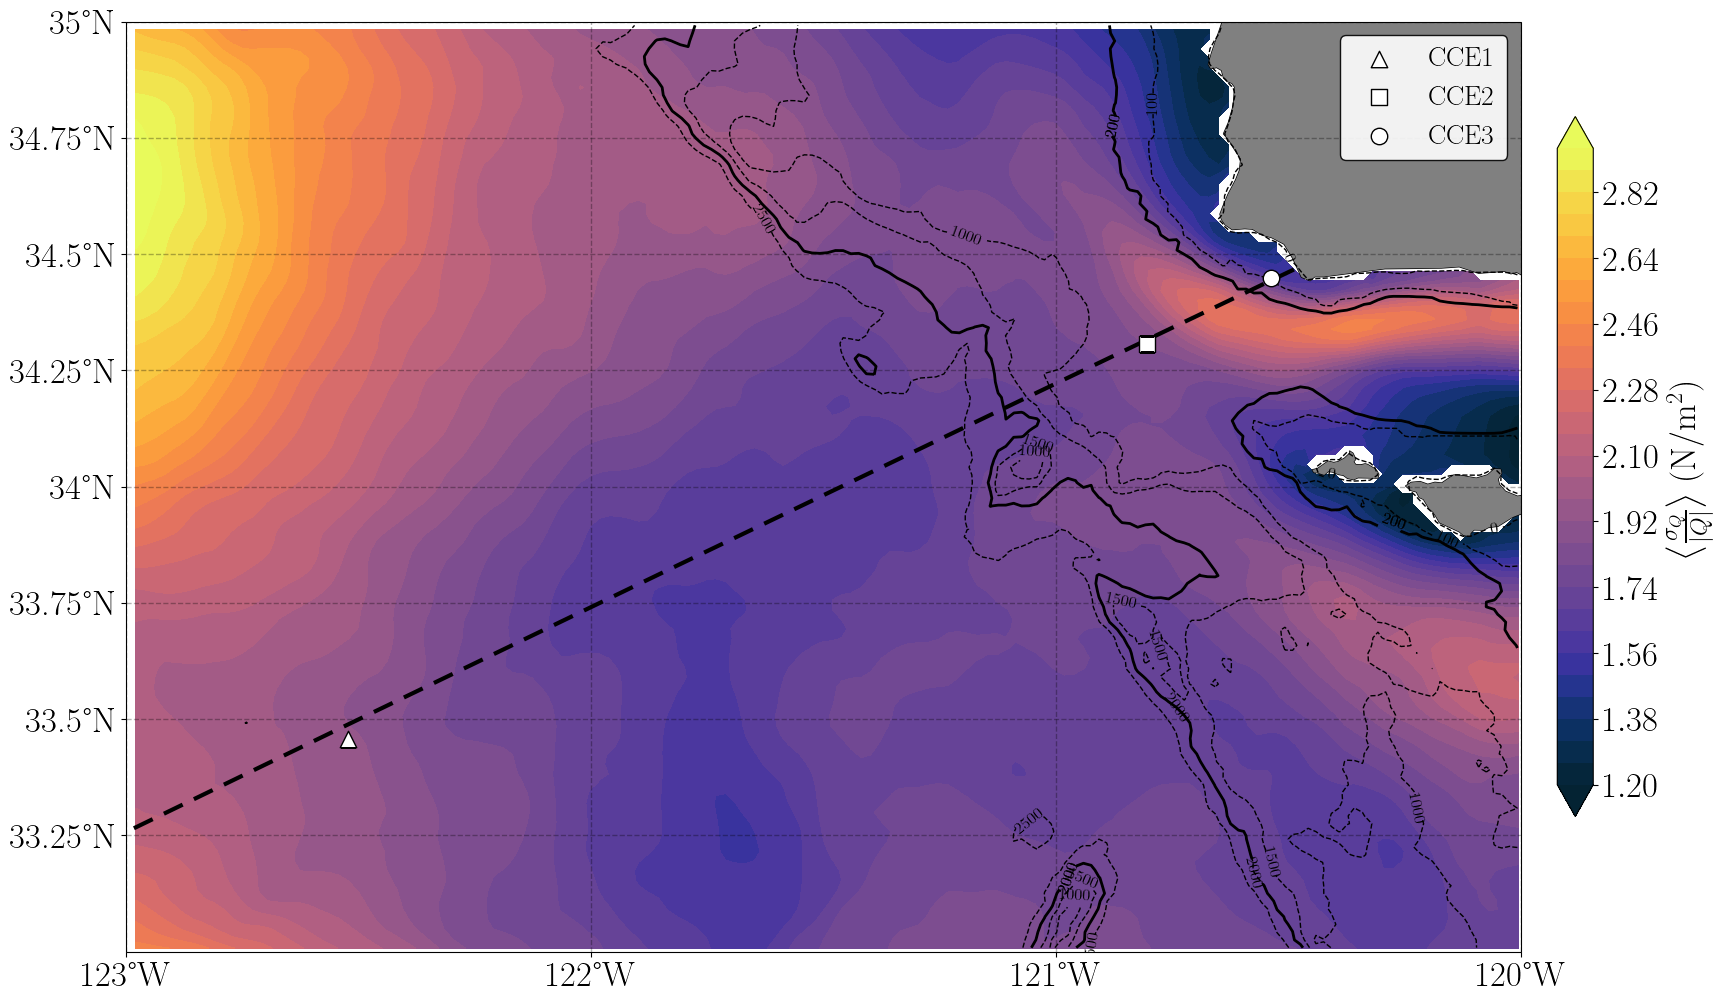

In [29]:
# Set plotting parameters
label_mean = r'$\big\langle \frac{\sigma_{Q}}{\lvert Q\rvert} \big\rangle$ (N/m$^2$)'
levels_mean = np.arange(0.03, 0.1+0.0025, 0.0025)

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of speed of the velocity
cf = axes.contourf(
    lon, lat, Q_net_ratio, levels=30,
    transform=ccrs.PlateCarree(),
    cmap=cmo.thermal,  
    extend = 'both'
)

#--- CCE1 ---# 

# Plot the mooring point
axes.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

#--- CCE2 ---# 

# Plot the mooring point
axes.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

#--- CCE3 ---# 

# Plot the mooring point
axes.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
axes.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree()
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='max') 
cbar.set_label(label_mean)
#cbar.set_ticks(np.array([0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]))

# Set legend
axes.legend(
    loc='upper right',
    fontsize=fontsize-5,
    framealpha=0.9,
    edgecolor='black'
)

# Show the plot
plt.show()

# Save with high quality
# figName = 'figS23.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_28788/2455725985.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


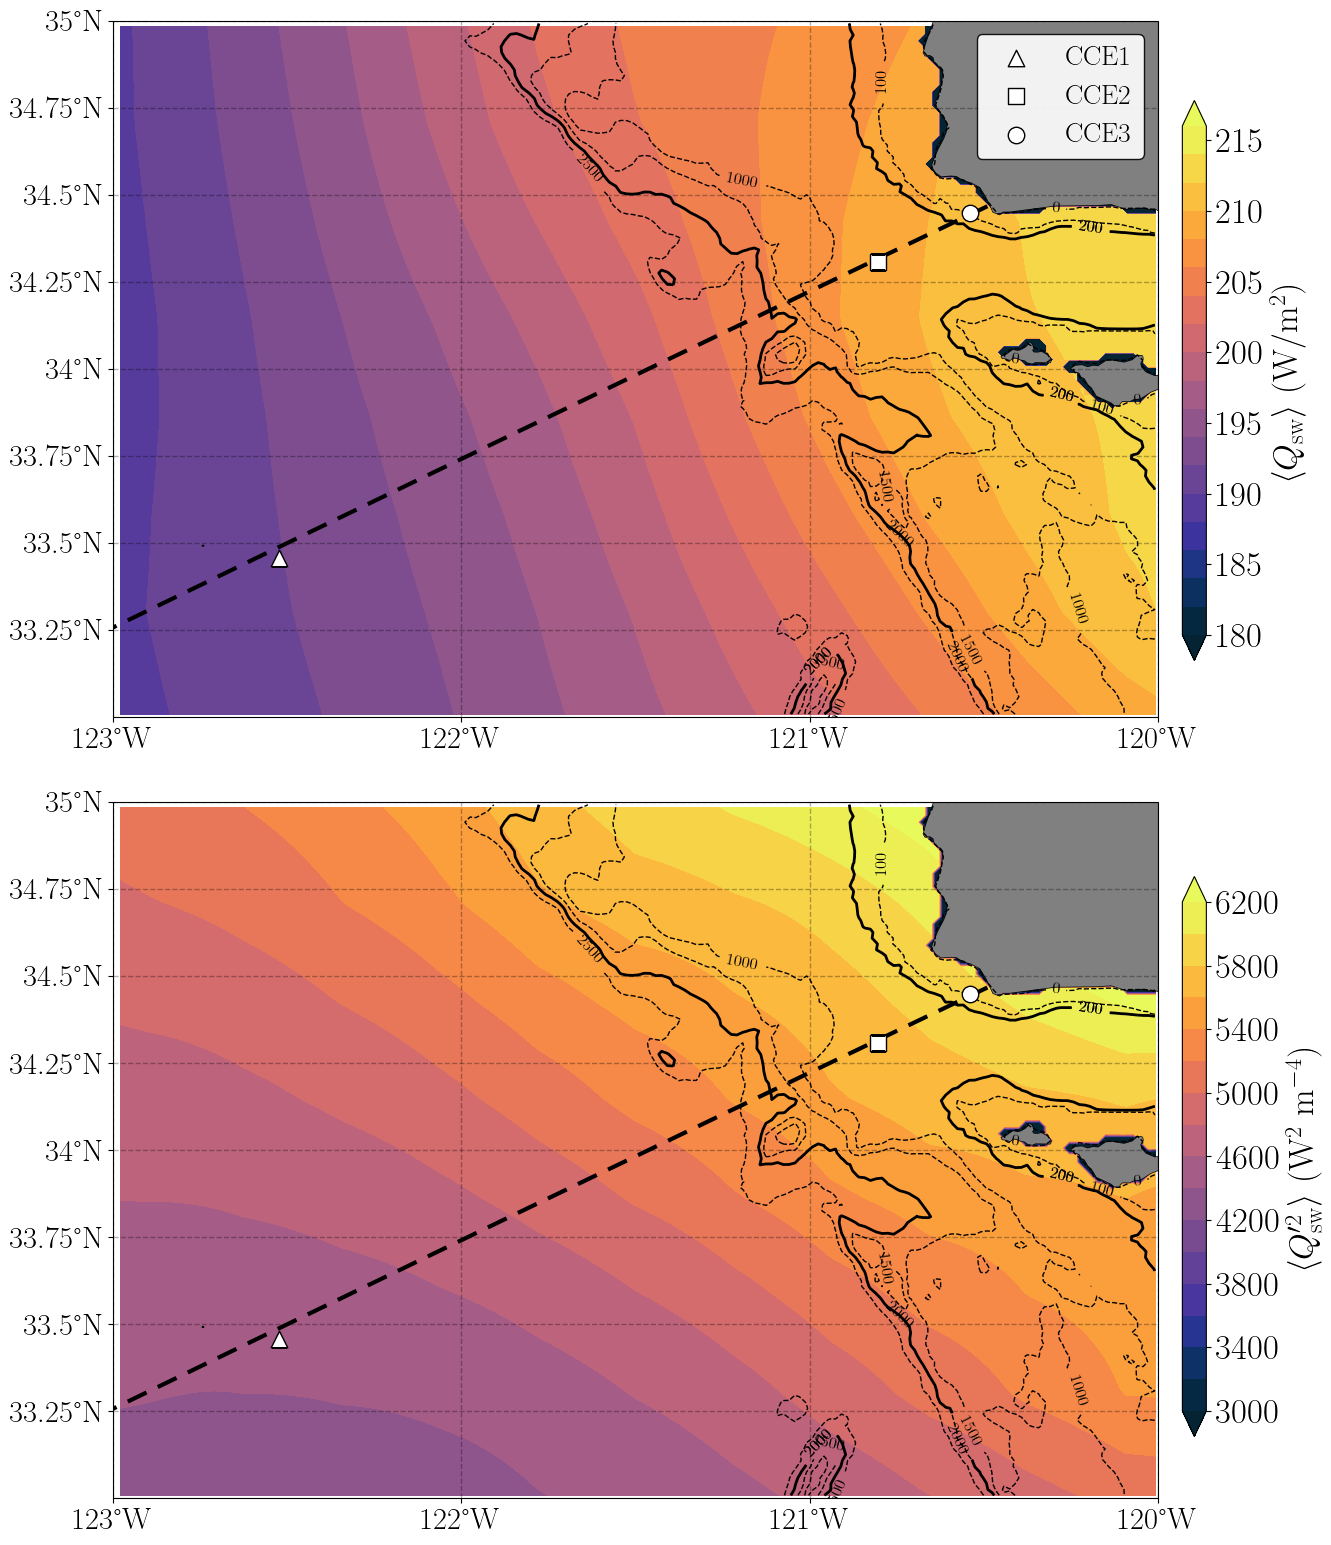

In [12]:
# Set plotting parameters
levels_mean = np.arange(180, 215+2, 2)
levels_var = np.arange(3000, 6200+200, 200)
cmap = cmo.thermal
label_mean = r'$\langle Q_{\mathrm{sw}} \rangle$ (W/m$^2$)'
label_var = r"$\langle Q_{\mathrm{sw}}'^2 \rangle$ (W$^2$ m$^{-4}$)"

# Create figure
fig, axes = plt.subplots(2,1, figsize=(12, 16), subplot_kw={"projection": projection})

#--- Subplot 1: Time Mean of Potential Density ---#
ax = axes[0]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_sw_mean, levels=levels_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree()
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colorbar
cax = plt.axes([0.98, 0.57, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_mean)
cbar.set_ticks(np.arange(180, 215+5, 5))   

# Set legend
ax.legend(
    loc='upper right',
    fontsize=fontsize-5,
    framealpha=0.9,
    edgecolor='black'
)

#--- Subplot 2: Time Variance of Potential Density ---#
ax = axes[1]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_sw_var, levels=levels_var,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.98, 0.085, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_var)
#cbar.set_ticks(np.arange(5000, 12000+1000, 1000)) 

# Show the plot
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'figS20.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_28788/681538378.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


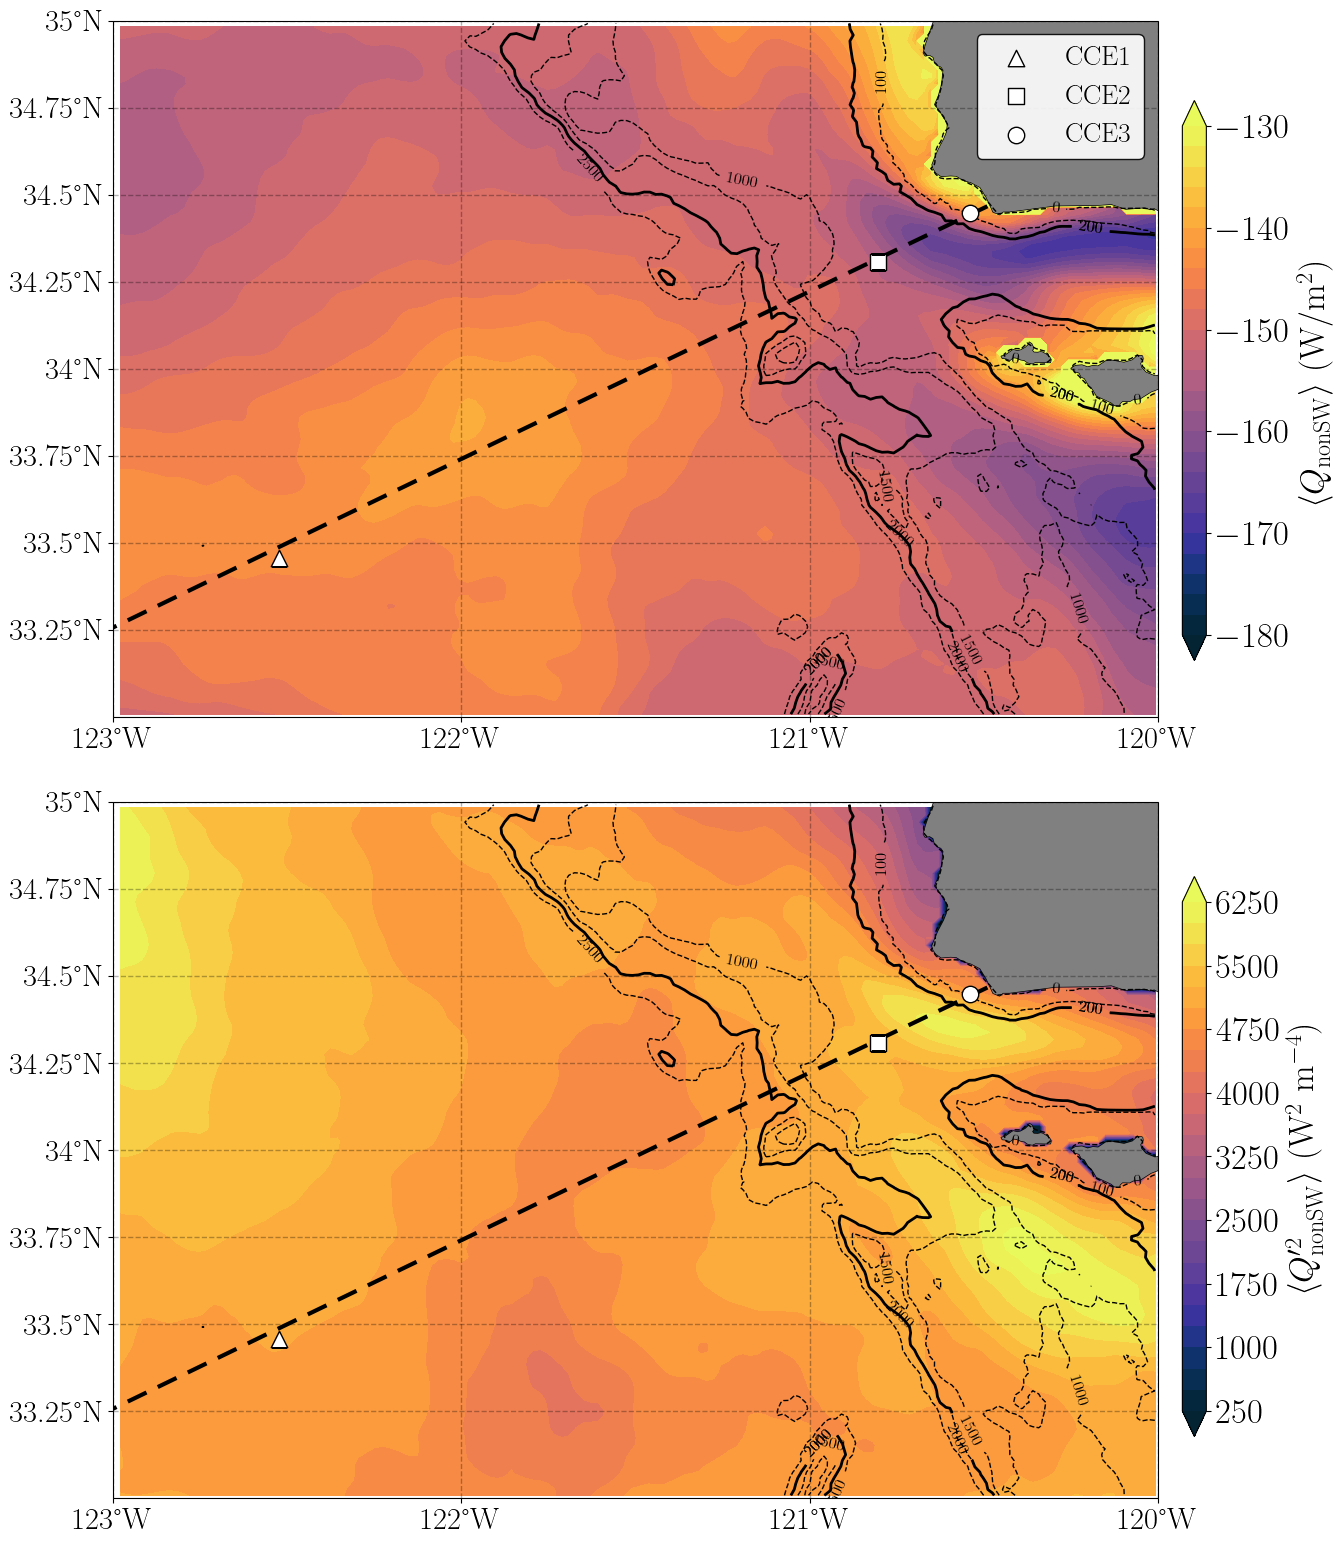

In [13]:
# Set plotting parameters
levels_mean = np.arange(-180, -130+2, 2)
levels_var = np.arange(5000, 12000+200, 200)
cmap = cmo.thermal
label_mean = r'$\langle Q_{\mathrm{nonSW}} \rangle$ (W/m$^2$)'
label_var = r"$\langle Q_{\mathrm{nonSW}}'^2 \rangle$ (W$^2$ m$^{-4}$)"

# Create figure
fig, axes = plt.subplots(2,1, figsize=(12, 16), subplot_kw={"projection": projection})

#--- Subplot 1: Time Mean of Potential Density ---#
ax = axes[0]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_nonsw_mean, levels=levels_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree()
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colorbar
cax = plt.axes([0.98, 0.57, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_mean)
cbar.set_ticks(np.arange(-180, -130+10, 10))   

# Set legend
ax.legend(
    loc='upper right',
    fontsize=fontsize-5,
    framealpha=0.9,
    edgecolor='black'
)

#--- Subplot 2: Time Variance of Potential Density ---#
ax = axes[1]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_nonsw_var, levels=30,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.98, 0.085, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_var)
#cbar.set_ticks(np.arange(5000, 12000+1000, 1000)) 

# Show the plot
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'figS20.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Compute magnitude of the spatial gradients 

In [14]:
#---------------------------# 
# Compute grid spacing in meters for the MITgcm grid
#---------------------------# 

# Earth radius (m)
R = 6371000  

# Convert to radians
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# Compute spacing
dlat = np.gradient(lat_rad)                # (lat,)
dlon = np.gradient(lon_rad)                # (lon,)

# Convert to meters
dy = R * dlat                              # (lat,)
dx = R * np.cos(lat_rad)[:, None] * dlon   # (lat, lon)

#---------------------------# 
# Compute spatial gradients 
#---------------------------#

# Compute gradients (axis: 1=lat, 2=lon)
dQ_net_dy = np.gradient(Q_net, axis=1) / dy[None, :, None]
dQ_net_dx = np.gradient(Q_net, axis=2) / dx[None, :, :]

dQ_nonSW_dy = np.gradient(Q_nonSW, axis=1) / dy[None, :, None]
dQ_nonSW_dx = np.gradient(Q_nonSW, axis=2) / dx[None, :, :]

# Gradient magnitude
Q_net_grad_mag = np.sqrt(dQ_net_dx**2 + dQ_net_dy**2)
Q_nonSW_grad_mag = np.sqrt(dQ_nonSW_dx**2 + dQ_nonSW_dy**2)

# Time average
Q_net_grad_mag_mean = np.mean(Q_net_grad_mag, axis=0) 
Q_nonSW_grad_mag_mean = np.mean(Q_nonSW_grad_mag, axis=0)

Q_net_grad_mag_var = np.var(Q_net_grad_mag, ddof=1,axis=0) 
Q_nonSW_grad_mag_var = np.var(Q_nonSW_grad_mag, ddof=1, axis=0)

Plot spatial gradients of net surface heat flux and non-solar surface heat flux

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_28788/1332115813.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


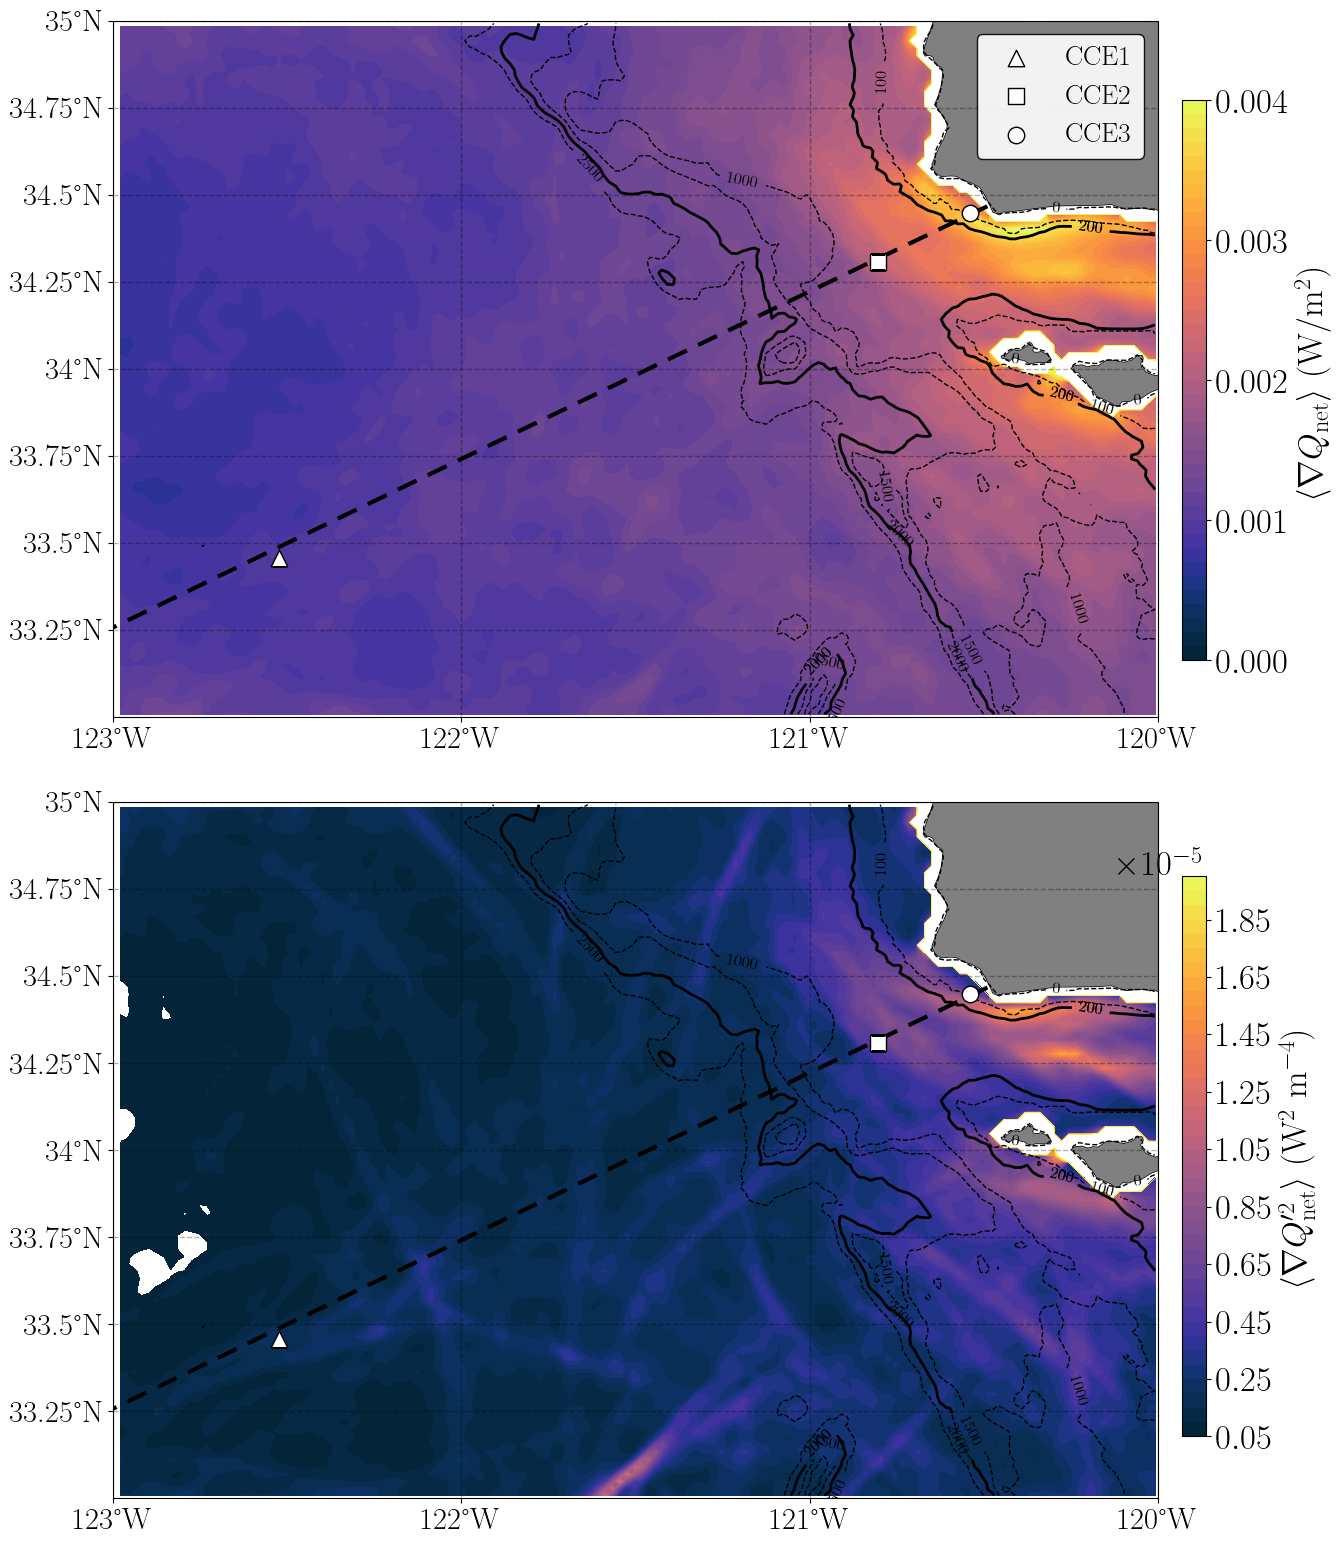

In [24]:
# Set plotting parameters
levels_mean = np.arange(0, 0.004+0.0001, 0.0001) 
levels_var = np.arange(0.0000005, 0.00002+0.00000005, 0.0000005)
cmap = cmo.thermal
label_mean = r'$\langle \nabla Q_{\mathrm{net}} \rangle$ (W/m$^2$)'
label_var = r"$\langle \nabla Q_{\mathrm{net}}'^2 \rangle$ (W$^2$ m$^{-4}$)"

# Create figure
fig, axes = plt.subplots(2,1, figsize=(12, 16), subplot_kw={"projection": projection})

#--- Subplot 1: Time Mean of Potential Density ---#
ax = axes[0]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_net_grad_mag_mean, levels=levels_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'neither'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree()
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colorbar
cax = plt.axes([0.98, 0.57, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_mean)
cbar.set_ticks(np.arange(0, 0.004+0.001, 0.001))   

# Set legend
ax.legend(
    loc='upper right',
    fontsize=fontsize-5,
    framealpha=0.9,
    edgecolor='black'
)

#--- Subplot 2: Time Variance of Potential Density ---#
ax = axes[1]

# Set figure axes 
cart.set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot the time mean of the potential density 
cf = ax.contourf(
    lon, lat, Q_net_grad_mag_var, levels=levels_var,
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    extend = 'neither'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

#--- CCE Moorings ---# 

# Plot the mooring point
ax.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE1'
)

# Plot the mooring point
ax.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE2'
)

# Plot the mooring point
ax.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=140,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10, 
    label='CCE3'
)

# Plot Line 80 CalCOFI Stations
ax.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='k',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Set grid ticks 
cart.set_grid_ticks(
    ax,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.98, 0.085, 0.02, 0.35])
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label_var)
#cbar.set_ticks(np.arange(5000, 12000+1000, 1000)) 

# Show the plot
plt.tight_layout()
plt.show()

# Save with high quality
# figName = 'figS20.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )
